In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
import datatools.datatools as tools
import moviepy.video.io.ImageSequenceClip 

In [2]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = './data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']


In [3]:
Eta_files , Eta_filepaths= tools.get_data_paths_from_binary(path_tohd, variables[0],file_end='nc')

In [4]:
Eta_ds = xr.open_mfdataset(Eta_filepaths)

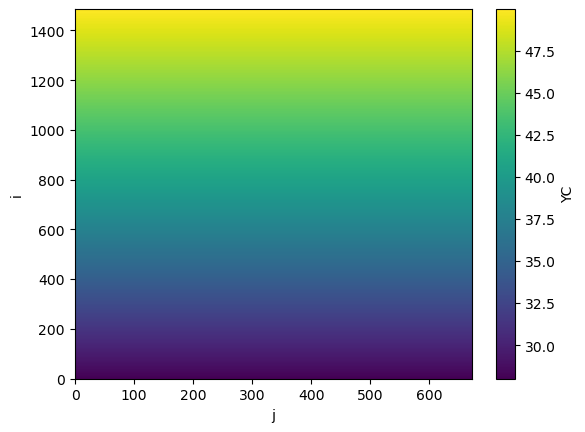

In [12]:
grid['YC'].plot()

In [13]:
Eta = xr.merge([Eta_ds,grid])

In [16]:
Eta=Eta.set_coords({'XC','YC'})
extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
ds = Eta
ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
ds_cut = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

#cape_mend = ds.sel(XC=slice(extent[0],extent[1]),YC=slice(extent[2],extent[3]))
#cape_mend.isel(time=0,k=0).plot()

In [42]:
ds_cut = ds_cut.sel(time=slice('2012-02-09T13:00:00','2012-02-16T09:00:00'))

In [49]:
## HIGH RES MODEL DATA
path_model = '/media/drdarby/Elements/data/model_output_cape_mend/'
data_path_model = path_model + 'hourly_data/nc_files/'

files, file_paths = tools.get_data_paths_from_binary(data_path_model,'Eta/Eta_ave',file_end='nc')
Eta_model = xr.open_mfdataset(file_paths)


In [66]:
np.asarray(Eta_model['time'][i].dt.strftime("20%y-%m-%d hour: %H "))

array('2012-02-09 hour: 13 ', dtype=object)

Text(0.5, 1.0, 'Eta scaledown model @ 2012-02-10 hour: 07 ')

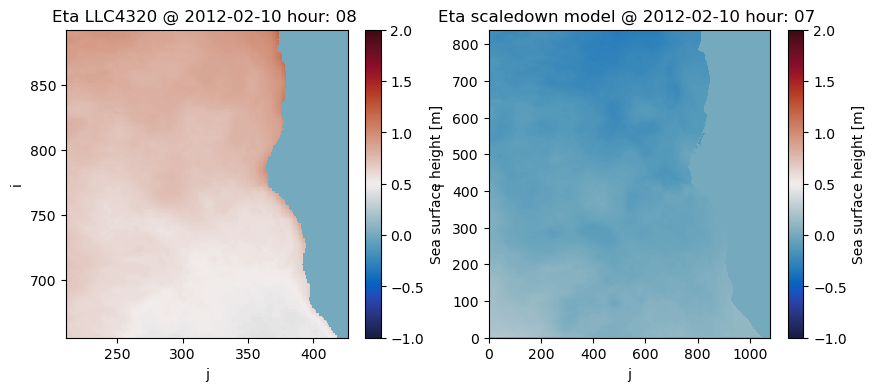

In [73]:
i=19
fig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
ds_cut['Eta'].isel(time=i).plot(cmap=cmocean.cm.balance,vmin=-1,vmax=2)
plt.title('Eta LLC4320 @ '+str(np.asarray(ds_cut['time'][i].dt.strftime("20%y-%m-%d hour: %H "))))
plt.subplot(1,2,2)
Eta_model['Eta_ave'].isel(time=0).plot(cmap=cmocean.cm.balance,vmin=-1,vmax=2)
plt.title('Eta scaledown model @ '+str(np.asarray(Eta_model['time'][i].dt.strftime("20%y-%m-%d hour: %H "))))

In [70]:
ds_cut['Eta'].attrs['long_name'] = 'Sea surface height [m]'
Eta_model['Eta_ave'].attrs['long_name'] = 'Sea surface height [m]'

for i in range(0,len(ds_cut.time)):
    fig = plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    ds_cut['Eta'].isel(time=i).plot(cmap=cmocean.cm.balance,vmin=-1,vmax=2)
    plt.title('Eta LLC4320 @ '+str(np.asarray(ds_cut['time'][i].dt.strftime("20%y-%m-%d hour: %H "))))
    plt.subplot(1,2,2)
    Eta_model['Eta_ave'].isel(time=i).plot(cmap=cmocean.cm.balance,vmin=-1,vmax=2)
    plt.title('Eta scaledown model @ '+str(np.asarray(Eta_model['time'][i].dt.strftime("20%y-%m-%d hour: %H "))))

    plt.savefig(f'/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/eta/eta_{i:04}.png')
    plt.close()

In [3]:
file_path = '/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/'
fps = 5
files,paths = tools.get_data_paths_from_binary(file_path,'vort_lcs_div',file_end='png')
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(paths,fps=fps)
clip.write_videofile(file_path+'../vort_div_test.mp4')

Moviepy - Building video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../vort_div_test.mp4.
Moviepy - Writing video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../vort_div_test.mp4



Moviepy - Done !
Moviepy - video ready /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../vort_div_test.mp4


In [7]:
file_path = '/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/'
fps = 5
files,paths = tools.get_data_paths_from_binary(file_path,'Filiment_points_rep',file_end='png')
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(paths,fps=fps)
clip.write_videofile(file_path+'../filiment_points_cs.mp4')

Moviepy - Building video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../filiment_points_cs.mp4.
Moviepy - Writing video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../filiment_points_cs.mp4



Moviepy - Done !
Moviepy - video ready /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../filiment_points_cs.mp4


In [8]:
file_path = '/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/'
fps = 5
files,paths = tools.get_data_paths_from_binary(file_path,'eddy_points_rep_attr',file_end='png')
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(paths,fps=fps)
clip.write_videofile(file_path+'../eddy_points_cs.mp4')

Moviepy - Building video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../eddy_points_cs.mp4.
Moviepy - Writing video /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../eddy_points_cs.mp4



Moviepy - Done !
Moviepy - video ready /media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/../eddy_points_cs.mp4


In [29]:
file_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/'
fps=5
files,paths = tools.get_data_paths_from_binary(file_path,'lcs_test_panels/lcs_test',file_end='png')
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(paths,fps=fps)
clip.write_videofile(file_path+'lcs_test_panels/../lcs_test.mp4')

KeyError: 'long_name'